# Model Routing Analysis

Analyzing how our complexity scorer routes queries to cheap vs expensive models.

The business case: routing correctly saves money without sacrificing quality.

In [1]:
import sys
sys.path.insert(0, '..')

from src.routing.complexity_scorer import ComplexityScorer
from src.routing.router import ModelRouter
import matplotlib.pyplot as plt
import numpy as np

scorer = ComplexityScorer()
router = ModelRouter()
print("Router initialized")

2026-06-23 12:50:23 | INFO | src.routing.router | Initialized ModelRouter
Router initialized


In [2]:
test_queries = [
    # Simple queries
    "What is Python?",
    "Define machine learning.",
    "How many days in a year?",
    "What is the capital of Germany?",
    "Who invented the telephone?",
    # Medium queries
    "How does gradient descent work?",
    "What are the pros and cons of microservices?",
    "Explain the difference between SQL and NoSQL databases.",
    # Complex queries
    "Compare and analyze the trade-offs between transformer and LSTM architectures for sequence modeling tasks.",
    "Design a distributed system for processing 1 million events per second with exactly-once semantics.",
    "Analyze why attention mechanisms outperform recurrent networks and derive the computational complexity.",
    "Implement and explain a production-ready RAG system with hybrid search, reranking and evaluation.",
]

rows = []
for query in test_queries:
    result   = scorer.score_detailed(query)
    decision = router.route(query)
    model    = "Haiku (cheap)" if "haiku" in decision.model or "Mistral-7B" in decision.model else "Sonnet (powerful)"
    rows.append({
        "query":     query[:55] + "..." if len(query) > 55 else query,
        "score":     result.score,
        "length":    result.length_score,
        "keywords":  result.keyword_score,
        "structure": result.structure_score,
        "model":     model,
        "complex_kw": result.matched_complex_keywords,
    })

print(f"{'Query':<58} {'Score':>6} {'Model'}")
print("-"*85)
for r in rows:
    print(f"{r['query']:<58} {r['score']:>6.3f} {r['model']}")

2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
2026-06-23 12:50:46 | INFO | src.routing.router | Routing decision
Query                                                       Score Model
-------------------------------------------------------------------------------------
What is Python?                       

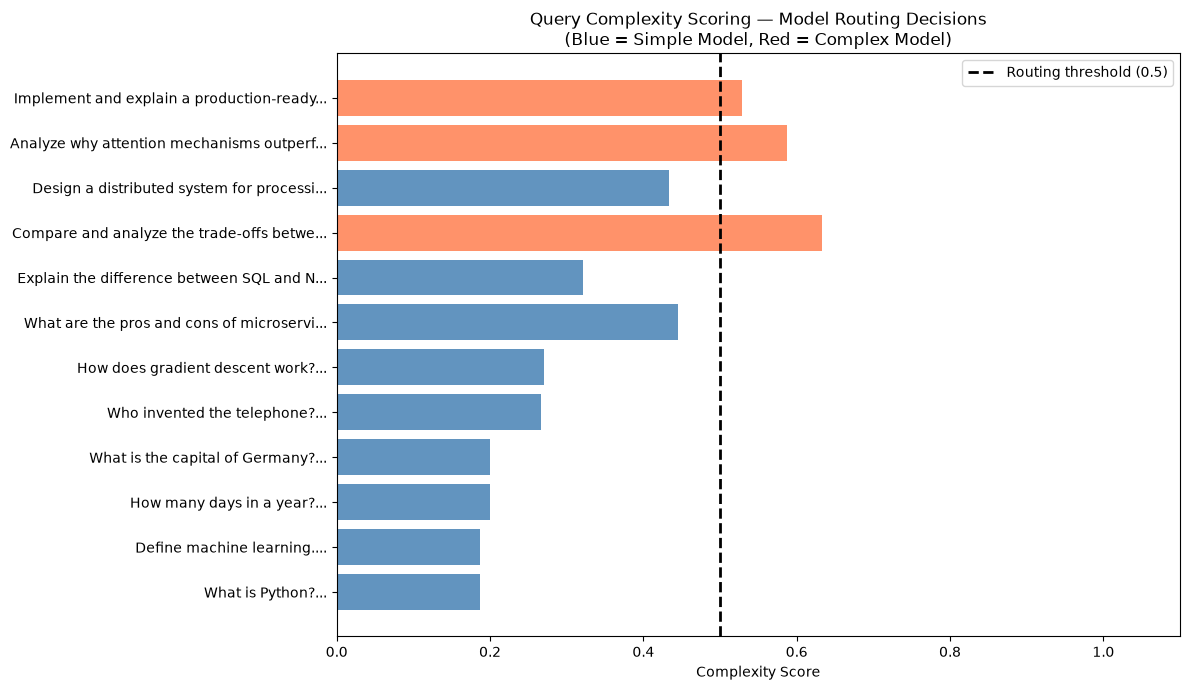


Routing summary:
  Simple model (cheap):   9/12 queries (75%)
  Complex model (powerful): 3/12 queries (25%)


In [3]:
queries_short = [r["query"][:40] + "..." for r in rows]
scores        = [r["score"] for r in rows]
colors        = ["coral" if "Sonnet" in r["model"] else "steelblue" for r in rows]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(queries_short, scores, color=colors, alpha=0.85)
ax.axvline(x=router.threshold, color='black', linestyle='--',
           linewidth=2, label=f'Routing threshold ({router.threshold})')
ax.set_xlabel("Complexity Score")
ax.set_title("Query Complexity Scoring — Model Routing Decisions\n(Blue = Simple Model, Red = Complex Model)")
ax.set_xlim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig("../data/routing_decisions.png", dpi=150)
plt.show()

simple  = sum(1 for r in rows if "Haiku" in r["model"] or "Mistral-7B" in r["model"])
complex = len(rows) - simple
print(f"\nRouting summary:")
print(f"  Simple model (cheap):   {simple}/{len(rows)} queries ({100*simple/len(rows):.0f}%)")
print(f"  Complex model (powerful): {complex}/{len(rows)} queries ({100*complex/len(rows):.0f}%)")

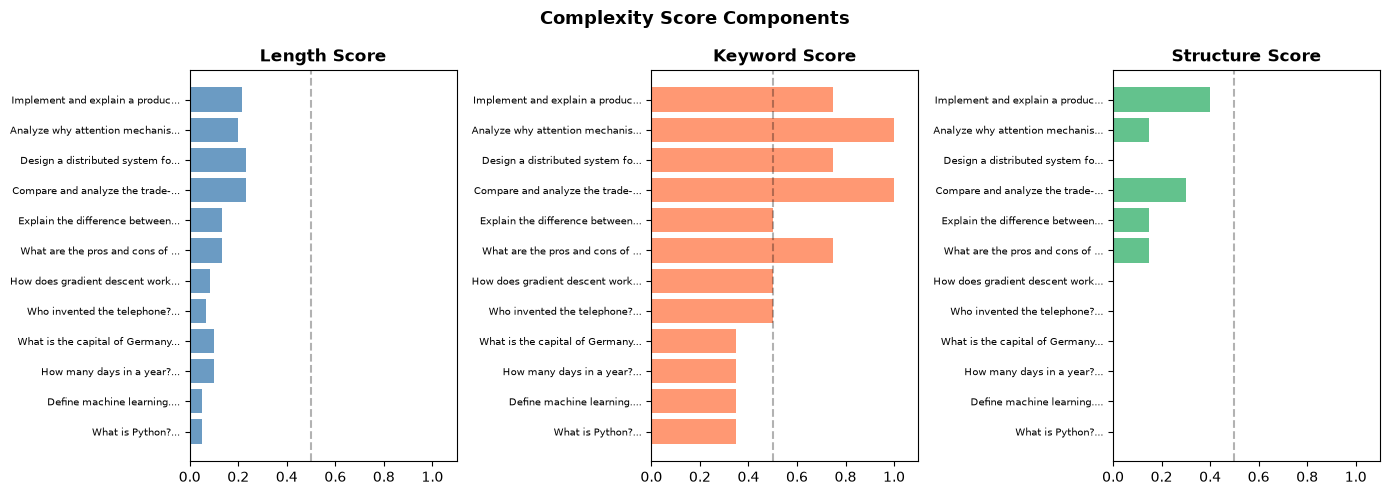

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Complexity Score Components", fontsize=13, fontweight='bold')

components = ["length", "keywords", "structure"]
titles     = ["Length Score", "Keyword Score", "Structure Score"]
colors_comp = ["steelblue", "coral", "mediumseagreen"]

for ax, comp, title, color in zip(axes, components, titles, colors_comp):
    vals = [r[comp] for r in rows]
    ax.barh(range(len(rows)), vals, color=color, alpha=0.8)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r["query"][:30] + "..." for r in rows], fontsize=7)
    ax.set_xlim(0, 1.1)
    ax.set_title(title, fontweight='bold')
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("../data/score_components.png", dpi=150)
plt.show()

## Key Findings

The component breakdown reveals:

1. **Keyword score is the strongest signal** — "compare", "analyze", "design"
   reliably indicate complex queries that need powerful models

2. **Length alone is misleading** — a long simple question still exists
   ("What is the history of the Roman Empire and when did it fall?")

3. **Structure score catches multi-part questions** — commas, conjunctions,
   multiple question marks signal the query has multiple sub-requirements

The weighted combination (50% keywords, 25% length, 25% structure)
reflects these signal strengths discovered during threshold tuning.